## **Ink-bleed detection — score distribution analysis**

Load the JSON produced by `run_ink_bleed_detection.py` and study the score distribution beyond what the run-summary captures by default. Use this to pick a stricter percentile (`p96`–`p99`) if the default `p75` flags too many images.

The detector writes:
- `summary.bleed_score_distribution` — min, p25, p50, p75, p95, max, mean.
- `summary.metric_normalization` — per-run min/max for the two sub-metrics (used during min-max rescale).
- `summary.effective_threshold` — the score cutoff the run actually applied (= the chosen percentile of `bleed_score`).
- `images[<rel_path>].bleed_score`, `.has_bleed`, `.metrics` — per-image record.

This notebook does **not** rerun detection. It only re-analyses an existing JSON, so you can pick a new percentile and see what would have been flagged without recomputing scores.

In [3]:
import json
import os
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from dotenv import load_dotenv

load_dotenv()
project_root = Path(os.environ.get("PROJECT_ROOT", "."))

# Edit this path to point at the run you want to analyse.
JSON_PATH = project_root / "data/processed/filtered_images/20260618_160948/ink_bleed_20260618_161555.json"

doc = json.loads(JSON_PATH.read_text(encoding="utf-8"))
summary = doc["summary"]
images  = doc["images"]

print(f"run: {summary['run']}")
print(f"images_dir: {summary['images_dir']}")
print(f"n_processed: {summary['n_processed']:,}  |  n_skipped: {summary['n_skipped']}")
print(f"chosen percentile: {summary.get('bleed_percentile', 'N/A')}")
print(f"effective_threshold: {summary.get('effective_threshold', 'N/A')}")
print(f"n_with_bleed (at effective threshold): {summary['n_with_bleed']:,}")

run: bleed_detection_20260618_161555
images_dir: data/processed/filtered_images/20260618_160948/original/kept
n_processed: 13,677  |  n_skipped: 0
chosen percentile: 95.0
effective_threshold: 0.3964317547937741
n_with_bleed (at effective threshold): 684


### Load per-image scores into a DataFrame

We keep just the columns we need for percentile analysis. `metrics.degenerate` is kept so we can flag single-tone images (their score is always 0 in this pipeline).

In [4]:
rows = []
for rel_path, entry in images.items():
    m = entry["metrics"]
    rows.append({
        "path": rel_path,
        "bleed_score": entry["bleed_score"],
        "has_bleed": entry["has_bleed"],
        "bg_std_norm": m["bg_std_norm"],
        "intermediate_ratio": m["intermediate_ratio"],
        "degenerate": m.get("degenerate", False),
    })
df = pd.DataFrame(rows)
print(f"rows: {len(df):,}  |  degenerate: {df['degenerate'].sum():,}")
df.head()

rows: 13,677  |  degenerate: 0


,path,bleed_score,has_bleed,bg_std_norm,intermediate_ratio,degenerate
0,05_garde_001/05_garde_001_line_0.png,0.514831,True,0.210911,0.041201,False
1,05_garde_001/05_garde_001_line_1.png,0.320681,False,0.166274,0.033738,False
2,05_garde_001/05_garde_001_line_10.png,0.404056,True,0.170063,0.059211,False
3,05_garde_001/05_garde_001_line_101.png,0.263516,False,0.153065,0.031636,False
4,05_garde_001/05_garde_001_line_11.png,0.409956,True,0.167893,0.064542,False


### Extra percentiles: p96, p97, p98, p99

Compute the high-end percentiles on the **full score distribution** (matching what the detector does — degenerates included as score 0). For each, count how many images would be flagged if you used that percentile as the threshold.

In [5]:
scores = df["bleed_score"].to_numpy()

wanted = [25, 50, 75, 95, 96, 97, 98, 99]
values = np.percentile(scores, wanted)

rows = []
for p, v in zip(wanted, values):
    # 'Flagged' means score strictly above the cutoff (matches the
    # detector's `> effective_threshold` rule).
    n_above = int((scores > v).sum())
    rows.append({
        "percentile": f"p{p}",
        "score_cutoff": round(float(v), 6),
        "n_flagged": n_above,
        "fraction_flagged": round(n_above / len(scores), 4),
    })
pct_df = pd.DataFrame(rows)
pct_df

,percentile,score_cutoff,n_flagged,fraction_flagged
0,p25,0.227491,10257,0.7499
1,p50,0.260522,6838,0.5000
2,p75,0.307094,3419,0.2500
3,p95,0.396432,684,0.0500
4,p96,0.406916,548,0.0401
5,p97,0.420810,411,0.0301
6,p98,0.441010,274,0.0200
7,p99,0.477626,137,0.0100


### Compare with what the run actually flagged

Cross-check: the `n_flagged` row matching the run's chosen percentile should equal `summary['n_with_bleed']` (off-by-a-few due to floating-point ties on the boundary).

In [11]:
chosen_p = summary.get("bleed_percentile", 95)
eff_thr  = summary.get("effective_threshold")

print(f"Run chose p{chosen_p} -> effective_threshold = {eff_thr}")
print(f"Recomputed p{chosen_p} from this notebook    = {np.percentile(scores, chosen_p):.6f}")
print(f"summary.n_with_bleed                          = {summary['n_with_bleed']:,}")
if eff_thr is not None:
    print(f"images with score > effective_threshold       = {int((scores > eff_thr).sum()):,}")

Run chose p95.0 -> effective_threshold = 0.3964317547937741
Recomputed p95.0 from this notebook    = 0.396432
summary.n_with_bleed                          = 684
images with score > effective_threshold       = 684


### Score distribution with percentile markers

Histogram of `bleed_score` with vertical lines at p75, p95, p96, p97, p98, p99. The denser the tail, the more flexibility you have to push the threshold up.

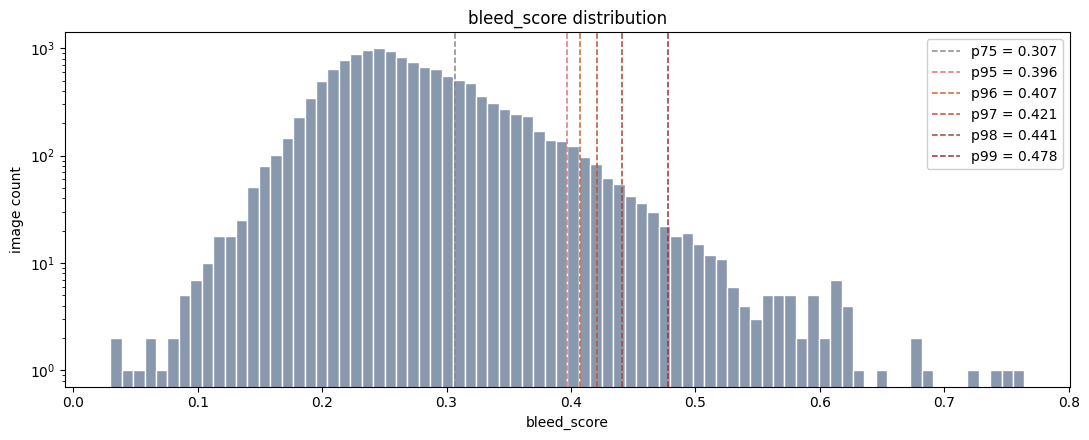

In [6]:
fig, ax = plt.subplots(figsize=(11, 4.5))
ax.hist(scores, bins=80, color="#8a98ad", edgecolor="white")

marker_pcts = [75, 95, 96, 97, 98, 99]
colors = ["#888", "#d77", "#c63", "#b53", "#a43", "#933"]
for p, c in zip(marker_pcts, colors):
    v = float(np.percentile(scores, p))
    ax.axvline(v, color=c, linestyle="--", linewidth=1.1, label=f"p{p} = {v:.3f}")

ax.set_xlabel("bleed_score")
ax.set_ylabel("image count")
ax.set_title("bleed_score distribution")
ax.legend(loc="upper right", framealpha=0.95)
ax.set_yscale("log")  # the tail is small; log-y makes p99 visible
plt.tight_layout()
plt.show()

### Top-20 worst images by `bleed_score`

Spot-check the highest-score images to confirm they actually look like bleed (and to catch any pathological case the heuristics get wrong).

In [13]:
top = df.sort_values("bleed_score", ascending=False).head(50)
top[["path", "bleed_score", "bg_std_norm", "intermediate_ratio", "degenerate", "has_bleed"]]

,path,bleed_score,bg_std_norm,intermediate_ratio,degenerate,has_bleed
13046,72_f_067v_068/72_f_067v_068_line_177.png,0.764367,0.258207,0.065379,False,True
7358,43_f_038v_039/43_f_038v_039_line_22.png,0.752719,0.218689,0.118269,False,True
13,05_garde_001/05_garde_001_line_2.png,0.741704,0.235719,0.089522,False,True
2522,18_f_013v_014/18_f_013v_014_line_170.png,0.721594,0.249650,0.061887,False,True
11883,66_f_061v_062/66_f_061v_062_line_27.png,0.690220,0.216031,0.098911,False,True
1390,12_f_007v_008/12_f_007v_008_line_33.png,0.678855,0.226966,0.078859,False,True
13047,72_f_067v_068/72_f_067v_068_line_178.png,0.672609,0.242335,0.054288,False,True
11885,66_f_061v_062/66_f_061v_062_line_29.png,0.649856,0.216940,0.082608,False,True
1294,12_f_007v_008/12_f_007v_008_line_129.png,0.635110,0.236740,0.048465,False,True
11884,66_f_061v_062/66_f_061v_062_line_28.png,0.625333,0.210876,0.082282,False,True


In [10]:
p99_cutoff = pct_df[pct_df['percentile']=='p99']['score_cutoff'].iloc[0]
pp99 = df[df['bleed_score'] >= p99_cutoff].sort_values("bleed_score", ascending=True)
pp99[["path", "bleed_score", "bg_std_norm", "intermediate_ratio", "degenerate", "has_bleed"]].head(20)

,path,bleed_score,bg_std_norm,intermediate_ratio,degenerate,has_bleed
3639,24_f_019v_020/24_f_019v_020_line_124.png,0.477697,0.200922,0.041875,False,True
111,06_f_001v_002/06_f_001v_002_line_107.png,0.477783,0.197907,0.046272,False,True
6,05_garde_001/05_garde_001_line_13.png,0.477897,0.191847,0.055088,False,True
467,07_f_002v_003/07_f_002v_003_line_75.png,0.478033,0.190778,0.056687,False,True
730,09_f_004v_005/09_f_004v_005_line_136.png,0.478378,0.178701,0.074300,False,True
365,07_f_002v_003/07_f_002v_003_line_155.png,0.480410,0.176574,0.078134,False,True
22,05_garde_001/05_garde_001_line_28.png,0.480449,0.190857,0.057469,False,True
400,07_f_002v_003/07_f_002v_003_line_188.png,0.481864,0.193240,0.054544,False,True
366,07_f_002v_003/07_f_002v_003_line_156.png,0.481922,0.187806,0.062434,False,True
1343,12_f_007v_008/12_f_007v_008_line_173.png,0.481999,0.196218,0.050282,False,True


### Sub-score correlation (sanity check)

If `bg_std_norm` and `intermediate_ratio` were perfectly correlated, the weighted combination wouldn't be doing much. A correlation below ~0.7 means the two signals capture genuinely different aspects of bleed and the weighted average is worth keeping.

Pearson r(bg_std_norm, intermediate_ratio) = 0.497  on 13,677 non-degenerate images


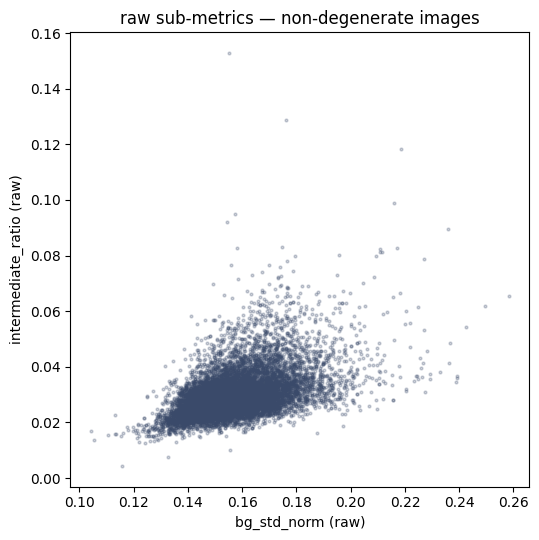

In [7]:
non_degen = df[~df["degenerate"]]
corr = non_degen[["bg_std_norm", "intermediate_ratio"]].corr().iloc[0, 1]
print(f"Pearson r(bg_std_norm, intermediate_ratio) = {corr:.3f}  on {len(non_degen):,} non-degenerate images")

fig, ax = plt.subplots(figsize=(5.5, 5.5))
ax.scatter(non_degen["bg_std_norm"], non_degen["intermediate_ratio"],
           s=4, alpha=0.25, color="#3a4a6a")
ax.set_xlabel("bg_std_norm (raw)")
ax.set_ylabel("intermediate_ratio (raw)")
ax.set_title("raw sub-metrics — non-degenerate images")
plt.tight_layout()
plt.show()